# IRRBB Model-Risk Case Study and Banking Architecture

## Executive decision

Two self-contained IRRBB prototypes were run through the same data contract, NMD calibration, banking book, cash-flow engine, Basel scenarios and NII simulation. The only intentional model change is the term-structure representation.

- **Four-factor Svensson:** superior out-of-sample reconstruction, but materially weaker factor identification.
- **Three-factor Nelson–Siegel:** slightly higher curve error, but much stronger numerical conditioning and structural level/slope/curvature alignment.
- **Recommended production architecture:** do not force one parametric model to serve every purpose. Use an approved market curve service for valuation, the three-factor model as the primary structural attribution model, and the four-factor model as a challenger/reconstruction benchmark subject to identification controls.
- **Business-critical finding:** reducing the assumed core NMD allocation to 80% of the base estimate pushes the illustrative adverse ΔEVE above the 15% Tier 1 threshold, while changing NS to Svensson barely moves the capital result. Behavioural-model governance dominates the curve-model choice in this book.

The delivered reference execution used the explicitly labelled offline panel because the build environment had no network. Both model notebooks default to `AUTO` and pull the official Federal Reserve `SVENY` data when available. No empirical market claim is made from the offline run.

## 1. Why IRRBB is a business problem before it is a curve-fitting problem

IRRBB is the risk to a bank's **capital and earnings** from adverse changes in interest rates. Basel treats it under Pillar 2 and distinguishes three sources:

1. **Gap risk:** timing mismatch in repricing and maturity, including parallel and non-parallel term-structure changes.
2. **Basis risk:** imperfect co-movement of different reference rates used to price economically similar positions.
3. **Option risk:** explicit or behavioural options, including loan prepayment, term-deposit early redemption and NMD stability/repricing.

An IRRBB framework therefore cannot begin with `fit_curve()`. It begins with governance, risk appetite, complete position data, approved behavioural assumptions, scenario design, capital and earnings measures, limit monitoring and independent validation. The curve model is one controlled component inside that architecture.

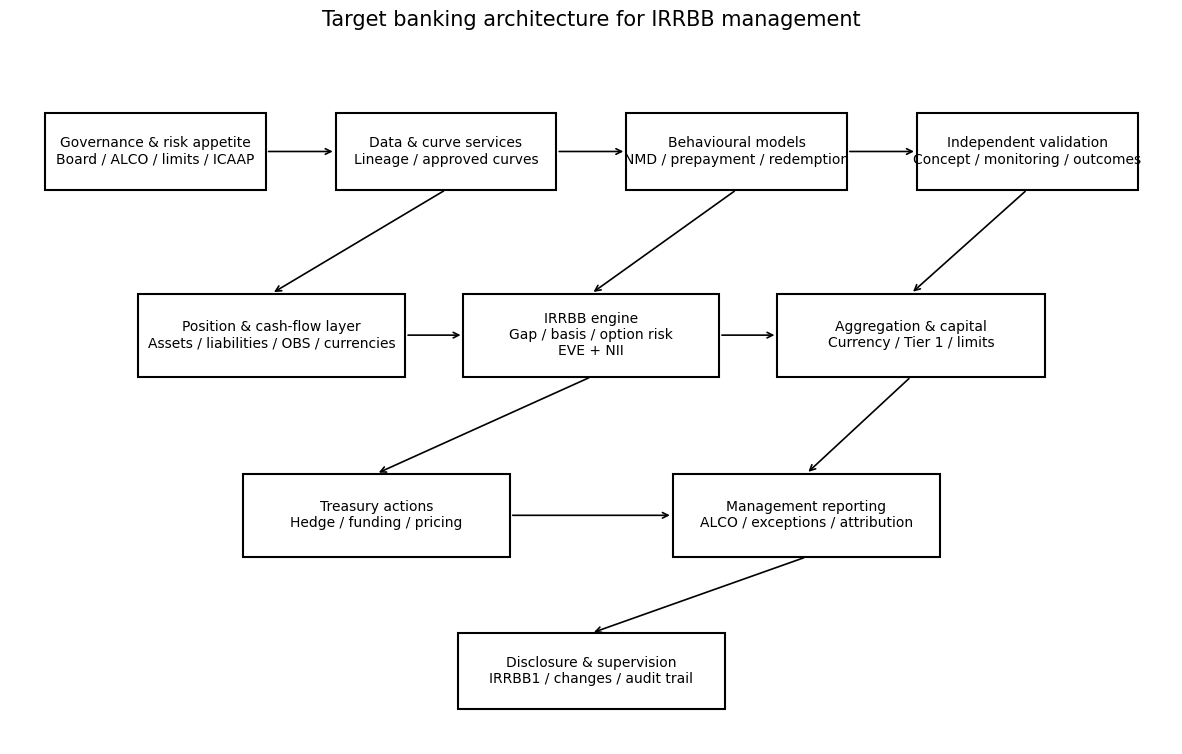

## 2. Target bank operating model

### 2.1 Governance and risk appetite

The governing body approves the IRRBB framework and risk appetite. ALCO or delegated senior management sets operational limits, reviews breaches, approves material assumptions and decides hedging, funding and pricing actions. Risk appetite must cover both economic value and earnings because EVE and NII reveal different horizons and different failure modes.

### 2.2 First line, second line and validation

- **Treasury/ALM:** owns balance-sheet strategy, funding, hedging and pricing actions; produces or operates the measurement process under approved policy.
- **Independent risk control:** challenges exposures, assumptions, limits and scenario adequacy; monitors model use and exceptions.
- **Independent model validation/internal audit:** assesses conceptual soundness, implementation integrity, ongoing performance, benchmarking, change control and governance evidence.

### 2.3 Data and position architecture

The production data layer must reconcile general ledger, product systems and off-balance-sheet instruments; retain currency, legal entity, contractual maturity, repricing date, index, caps/floors, behavioural attributes and optionality; and preserve lineage from source to ALCO report. The notebook's DataFrame is a compact data contract, not a substitute for those controls.

### 2.4 Behavioural-model inventory

NMD, prepayment and early-redemption models are separate governed models. Basel requires NMD segmentation and caps on core proportions and average maturities. Their outputs modify cash-flow timing and therefore feed both EVE and NII. They must be versioned, independently validated, backtested and subjected to assumption sensitivity.

### 2.5 Measurement and action loop

Approved market curves and behavioural cash flows feed EVE and NII engines. Results are aggregated by currency and legal entity, normalized against Tier 1 and earnings limits, attributed to business units and risk factors, and converted into hedge/funding/pricing actions. Reporting must preserve the bridge from exposure to management decision.

## 3. What the two model notebooks implement

Both notebooks implement the same controlled pipeline:

```text
configuration
    -> data provenance and temporal split
    -> curve calibration on train / selection on validation
    -> untouched test diagnostics
    -> NMD segmentation and governed ladder
    -> reconciled banking book + off-balance-sheet IRS
    -> cash-flow and valuation engine
    -> six prescribed EVE shocks + Tier 1 test
    -> monthly 12-month NII simulation
    -> key-assumption sensitivity
    -> assertions + versioned JSON/CSV/PNG artifacts
```

The notebooks deliberately remove the original trading appendix. A trading signal is a different use case, requires walk-forward signal estimation, transaction-cost and liquidity modelling, and should not be mixed into a regulatory/ALM engine merely because the same curve factors are available.

## 4. Code architecture and controls

### 4.1 Data provenance and no look-ahead

```python
zero_yields, DATA_SOURCE = load_zero_curve_panel()
train_panel = zero_yields.iloc[:train_end]
validation_panel = zero_yields.iloc[train_end:validation_end]
test_panel = zero_yields.iloc[validation_end:]
```

Decay parameters are estimated only from training data. Candidate calibrations are selected on validation RMSE. Test results are reported once, after hyperparameters are frozen. This removes the original full-sample leakage.

### 4.2 Linear-conditional curve fitting

```python
def fit_panel(panel_values, design):
    betas = np.linalg.lstsq(design, panel_values.T, rcond=None)[0].T
    fitted = betas @ design.T
    return betas, fitted
```

Conditional on the decay parameters, NS/NSS is linear in beta. Separating nonlinear decay calibration from linear daily beta fitting makes the numerical problem auditable and allows the loading matrix to be tested directly.

### 4.3 Identification is a model requirement

```python
design_condition = np.linalg.cond(design)
max_loading_corr = max_off_diagonal_abs_corr(design[:, 1:])
vif = variance_inflation_factors(design)
assert design_condition < 1_000
assert max_loading_corr < 0.995
```

The hard screens prevent a singular model from entering downstream risk calculations. They do not prove economic identification; PCA alignment, parameter stability and outcome analysis remain necessary.

### 4.4 Basel scenario implementation

```python
short = short_shock * np.exp(-times / 4.0)
long = long_shock * (1.0 - np.exp(-times / 4.0))
steepener = -0.65 * short + 0.90 * long
flattener =  0.80 * short - 0.60 * long
```

The engine calculates six EVE scenarios and compares the maximum adverse loss with 15% of Tier 1. It does not mislabel `ΔEVE / base EVE` as the supervisory test.

### 4.5 Monthly NII rather than a one-line approximation

```python
repriced = m >= reset_month
rate = base_rate + (beta * shock if repriced else 0.0)
monthly_nii = sign * notional * max(rate, 0.0) / 12.0
```

The NII path observes repricing dates, product betas and lags month by month under a constant-balance-sheet assumption. This remains an illustrative static simulation, but it is materially closer to an ALM earnings engine than multiplying a shock by a single exposure-period scalar.

## 5. Model results

| Metric | Four-factor Svensson | Three-factor Nelson–Siegel | Interpretation |
|---|---:|---:|---|
| Test mean RMSE | 0.496 bp | 0.556 bp | Svensson reconstructs the curve more closely. |
| Test 95th-percentile RMSE | 0.744 bp | 0.828 bp | Both are stable on the held-out sample. |
| Design condition number | 231.5 | 17.5 | Svensson is far more sensitive to small data perturbations. |
| Maximum loading correlation | 0.984 | 0.545 | The extra Svensson curvature competes with existing loadings. |
| \|corr(PC1, Δβ0)\| | 0.246 | 0.924 | NS recovers the empirical level factor; Svensson beta0 does not. |
| Mean matched PC–beta correlation | 0.201 | 0.933 | Structural interpretability is materially stronger in NS. |
| Worst ΔEVE / Tier 1 | 14.74% | 14.74% | Downstream capital results are close relative to identification differences. |
| ΔNII parallel up | 1.885 mm | 1.885 mm | NII is driven mainly by repricing architecture and deposit beta. |
| ΔNII parallel down | -2.482 mm | -2.482 mm | Asymmetric deposit pass-through creates asymmetric earnings risk. |

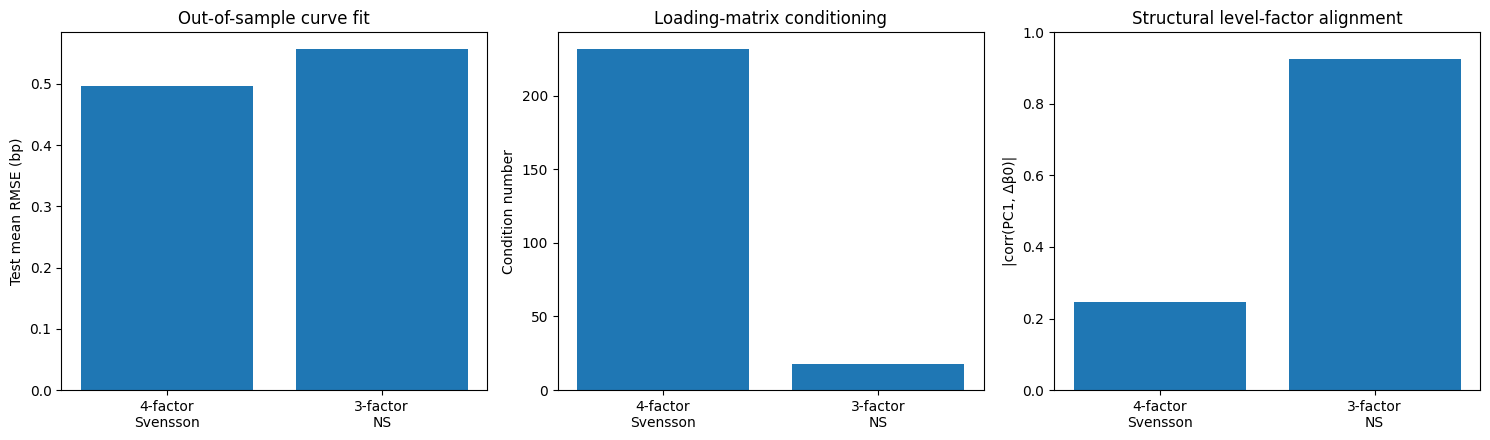

## 6. Diagnostic evidence from each engine

### Four-factor Svensson

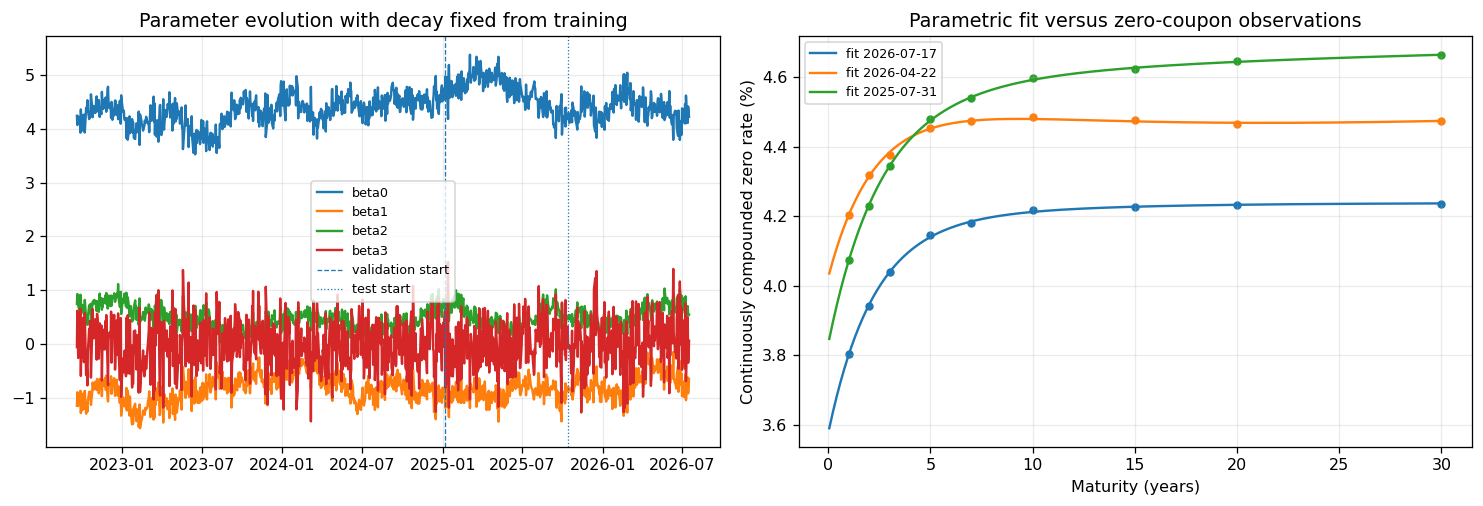

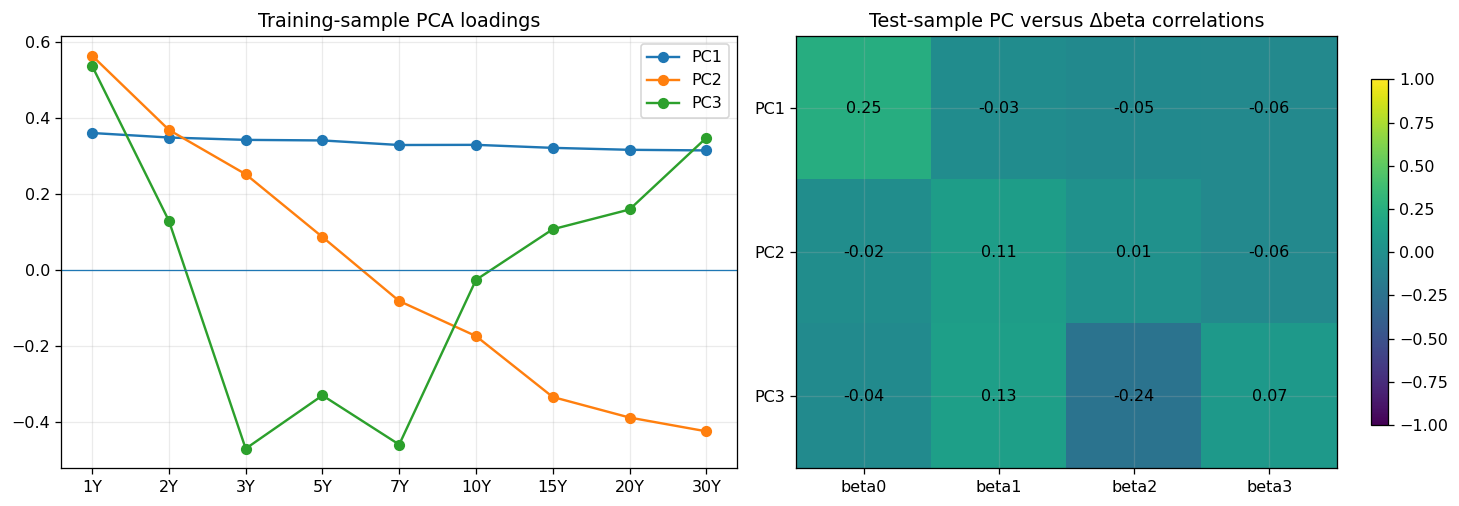

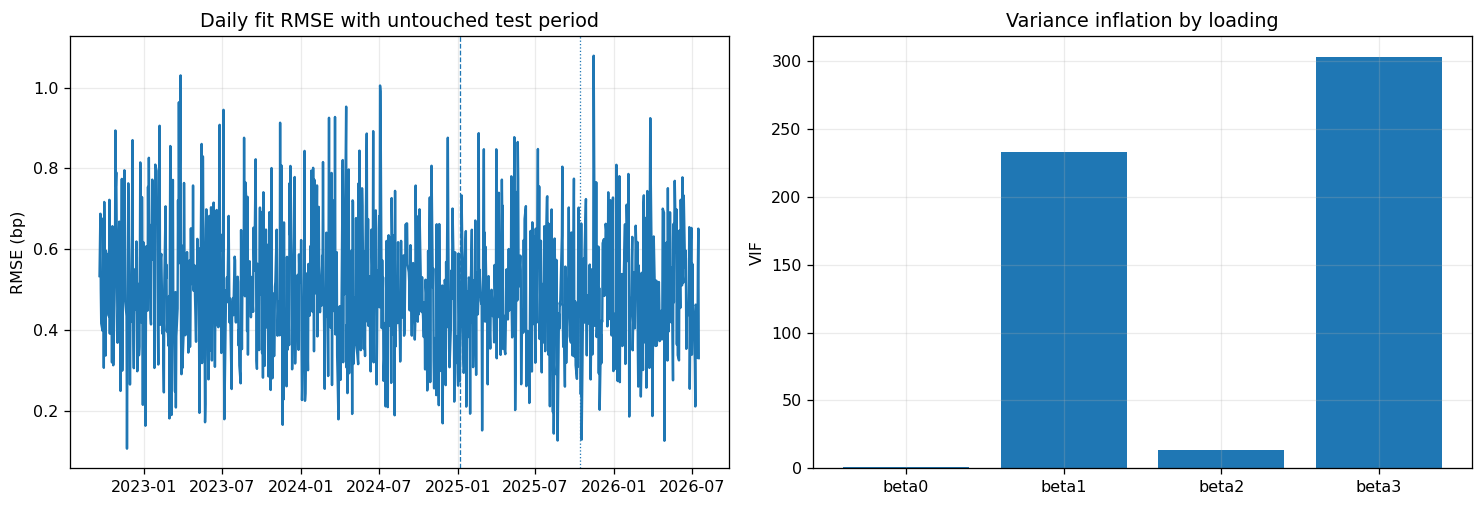

The fourth factor reduces residual curve error, but the improvement is purchased with a much more ill-conditioned loading matrix. Test-period PCA changes cannot be mapped cleanly to the daily beta changes. This is a parameter-identification problem, not merely a plotting anomaly.

### Three-factor Nelson–Siegel

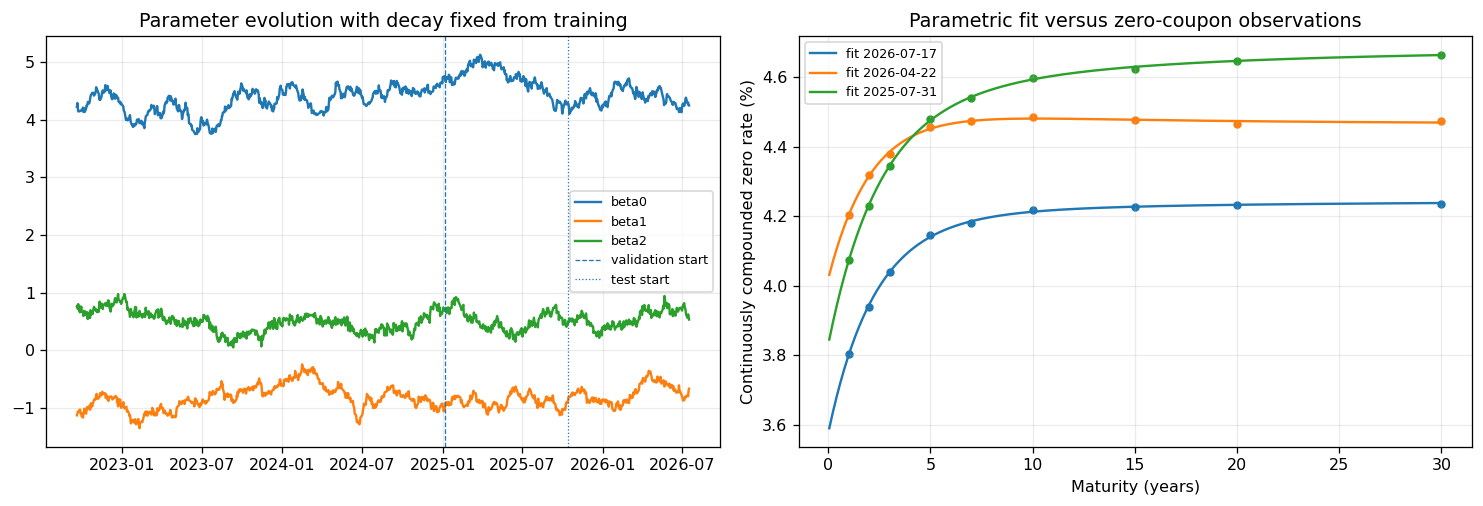

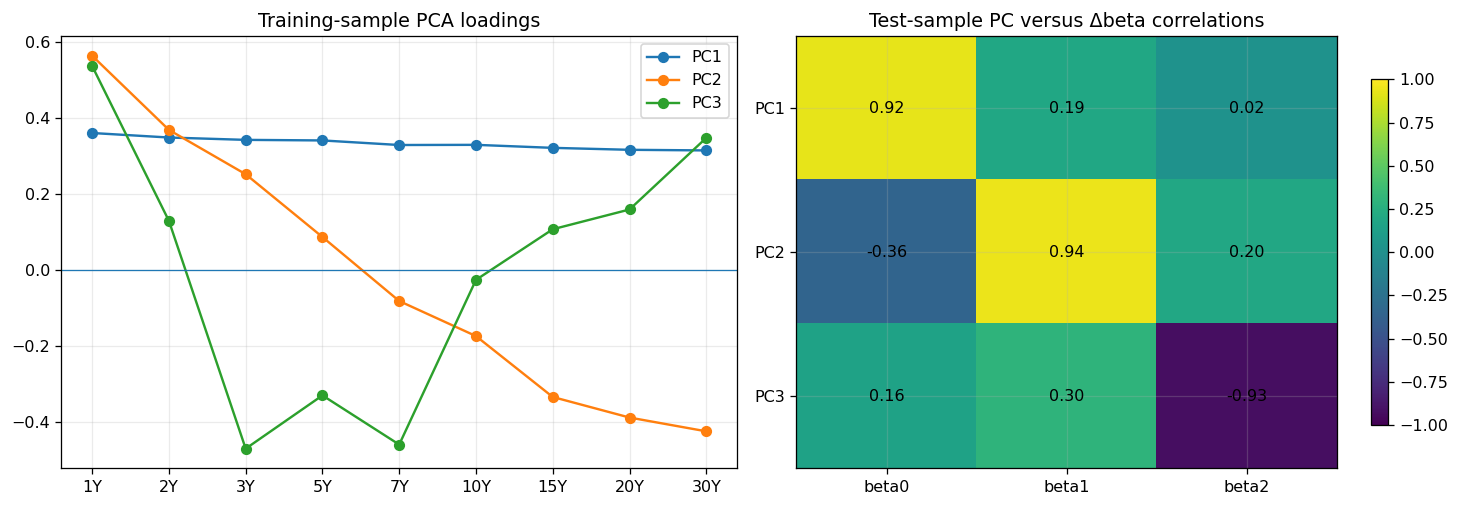

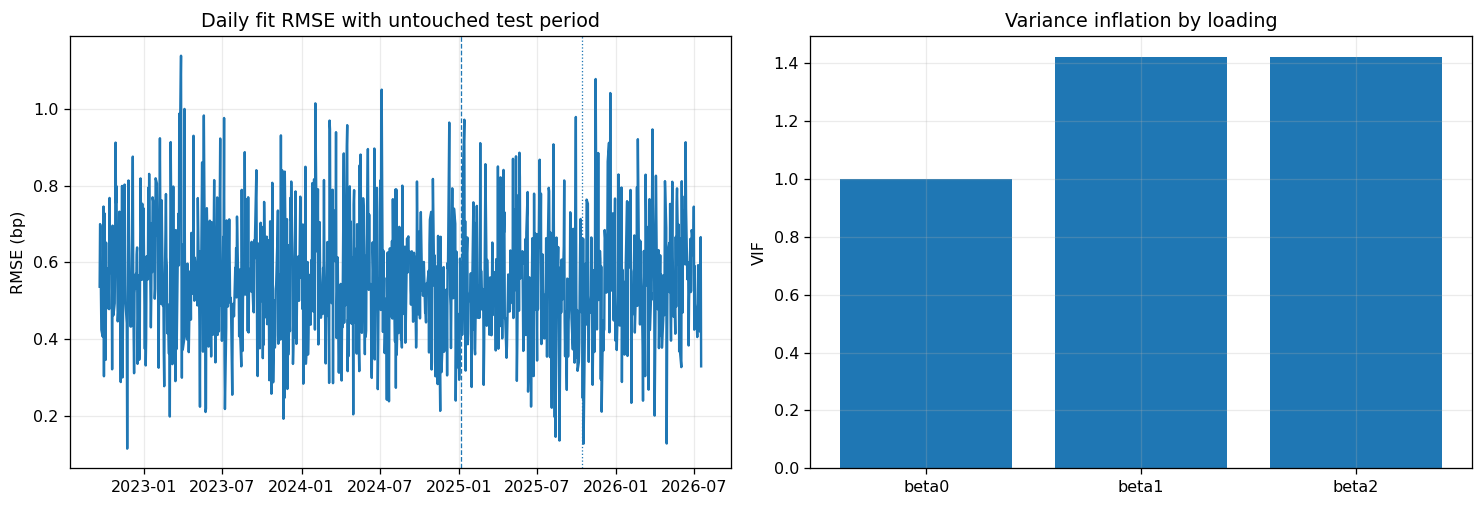

The NS model accepts a modest reconstruction penalty and produces a substantially better-conditioned, economically interpretable factor system. The held-out PCA level, slope and curvature factors map strongly to the structural beta changes.

## 7. EVE and NII implications

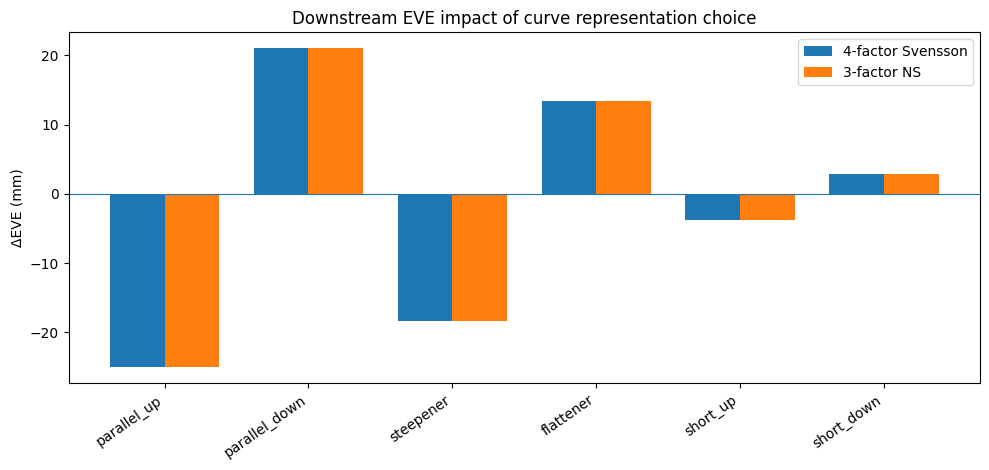

The worst prescribed EVE scenario is **parallel_up** for the three-factor model and **parallel_up** for the four-factor model. The maximum adverse losses are 25.050 mm and 25.051 mm respectively, versus Tier 1 capital of 170.0 mm.

The central model-risk result is not that the two representations produce identical valuations. It is that the downstream EVE/NII difference is small relative to the difference in parameter identification. This weakens the business case for using the extra Svensson factor as the primary structural risk-factor model.

### Why downstream similarity does not validate unstable factors

EVE is a portfolio-level functional of the fitted curve. Collinear beta coefficients can offset each other and produce a stable fitted curve even while individual factors are unstable. Therefore:

- low valuation difference does **not** prove the beta decomposition is sound;
- unstable factors can still corrupt attribution, limits, hedging narratives and management explanations;
- valuation and structural-factor models should be governed as distinct use cases.

### Behavioural-assumption sensitivity

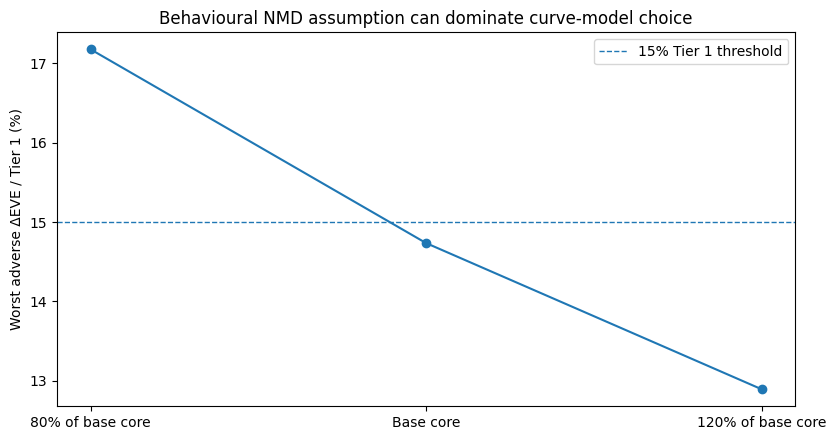

At 80% of the base core-deposit allocation, the worst adverse ΔEVE rises above the 15% Tier 1 outlier threshold; at 120%, it falls materially below the base case. The book is therefore more sensitive to the NMD behavioural assumption than to the difference between the two parametric curve representations.

### NMD and earnings architecture

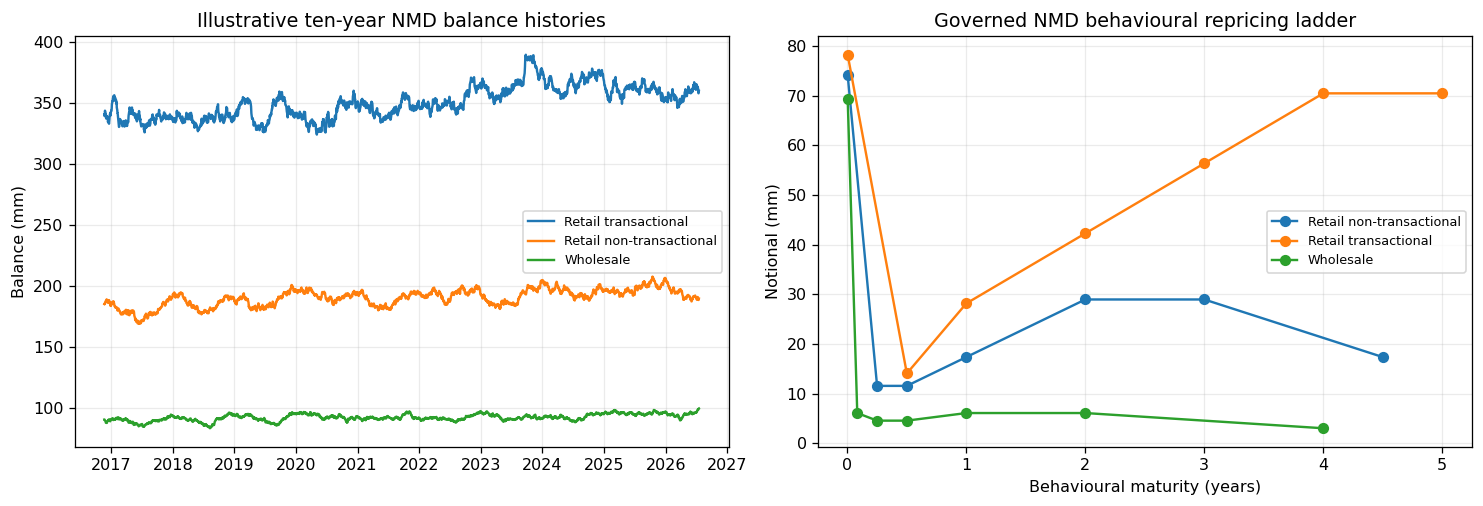

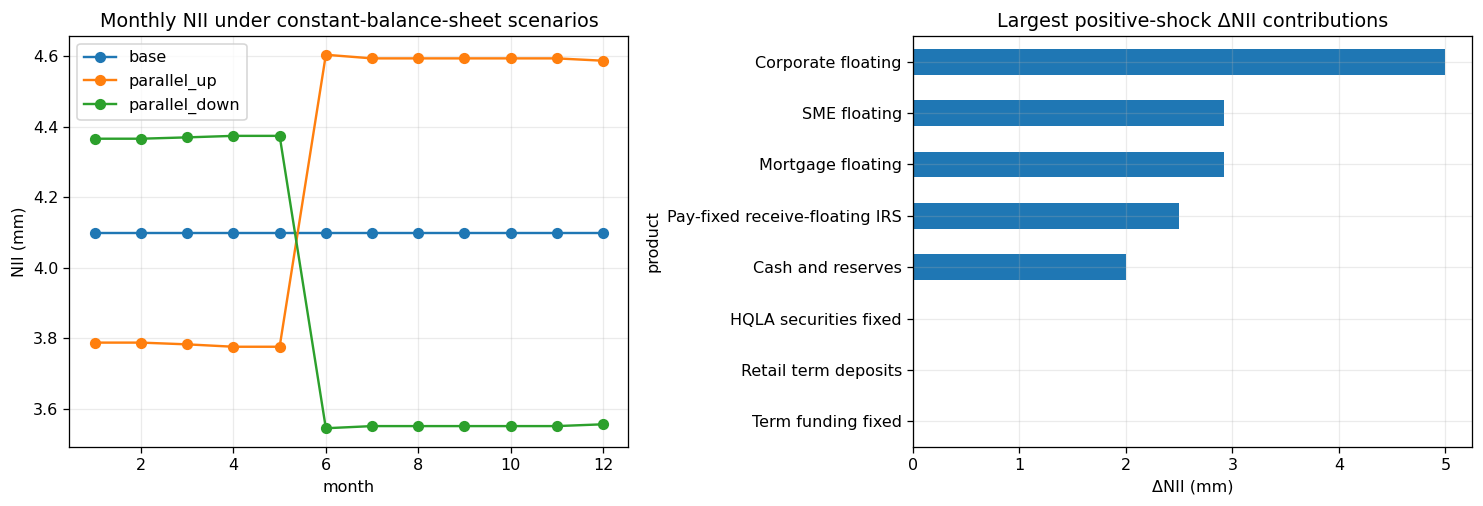

The NII result is determined principally by asset/liability repricing gaps, deposit betas, lags and the hedge. Curve representation matters less over a 12-month parallel-shock horizon than it does for long-horizon EVE. This is precisely why Basel requires both economic-value and earnings measures.

## 8. Model-risk assessment

### 8.1 Conceptual soundness

- **Svensson:** appropriate as a flexible curve representation and challenger; weak as a structural four-factor attribution model on this tenor grid unless identification improves materially.
- **Nelson–Siegel:** appropriate as a parsimonious level/slope/curvature benchmark; residual long-end shape error must be monitored and should not be hidden.
- **Valuation boundary:** neither parametric factor model should automatically replace the bank's approved discount/projection curve infrastructure.

### 8.2 Implementation verification

The two notebooks share identical input contracts and downstream engines. Assertions cover reconciliation, units, shock signs, NMD caps, condition limits and aggregation. Results are saved to a common artifact schema, reducing narrative/output drift.

### 8.3 Ongoing monitoring

Production monitoring should include:

- train/validation/test or rolling-origin reconstruction error;
- condition number, VIF and loading correlations;
- beta jump and drift thresholds;
- PCA/challenger factor alignment;
- valuation and hedge sensitivity to model choice;
- NMD, prepayment and early-redemption backtests;
- EVE/NII sensitivity to behavioural assumptions;
- data-quality, reconciliation and stale-market-data controls.

### 8.4 Change and exception governance

A model change should document purpose, affected reports, validation evidence, parallel run, threshold impacts, user acceptance, approvals and rollback plan. Exceptions to condition/factor-alignment thresholds should be time-bounded and visible to ALCO and independent risk control.

## 9. Final recommendation

### Primary architecture

1. **Approved market curve service for valuation and scenario discounting.** Build or source risk-free and projection curves using the bank's approved market-data and instrument conventions. Do not describe a Fed-smoothed curve refit as primary curve construction.
2. **Three-factor Nelson–Siegel as the primary structural attribution benchmark.** It gives a stable level/slope/curvature language for risk explanation, limit attribution and challenger analysis.
3. **Four-factor Svensson as a controlled challenger/reconstruction model.** Retain it to measure long-end shape residuals and model uncertainty, not as the sole source of economic factor labels.
4. **Separate behavioural-model inventory.** NMD, prepayment and early-redemption outputs should be approved inputs with their own validation, monitoring and overlays.
5. **EVE and NII as complementary decision measures.** EVE captures full-life economic-value sensitivity; NII captures shorter-horizon earnings sensitivity. Neither substitutes for the other.
6. **ALCO decision bridge.** Translate scenario losses into hedge, funding, product-pricing and capital actions with attribution and limit utilization.

### Portfolio-project verdict

The revised project is no longer a curve-fitting demo attached to a synthetic balance sheet. It is a coherent **IRRBB model-risk case study** with temporal validation, numerical identification, behavioural modelling, capital normalization, EVE/NII integration, assumption sensitivity, audit-friendly artifacts and a defensible production migration path. It remains honestly labelled as a prototype because real bank data, local supervisory implementation, production controls and independent validation are not available.

## 10. References

1. Basel Committee on Banking Supervision, **SRP31 — Interest rate risk in the banking book**, version effective 1 January 2026: https://www.bis.org/basel_framework/chapter/SRP/31.htm?inforce=20260101&published=20240716
2. Basel Committee on Banking Supervision, **Recalibration of shocks for interest rate risk in the banking book (d578)**, 16 July 2024: https://www.bis.org/bcbs/publ/d578.htm
3. Basel Committee on Banking Supervision, **SRP98 — Application guidance on IRRBB**: https://www.bis.org/basel_framework/chapter/SRP/98.htm?inforce=20260101&published=20240716
4. Basel Committee on Banking Supervision, **DIS70 — IRRBB disclosure requirements**: https://www.bis.org/basel_framework/chapter/DIS/70.htm
5. Federal Reserve Board, **Nominal Yield Curve — Gürkaynak, Sack and Wright data**: https://www.federalreserve.gov/data/nominal-yield-curve.htm

### Artifact lineage

- `artifacts/nss4/metrics.json` and associated CSV/PNG files are produced by Notebook 1.
- `artifacts/ns3/metrics.json` and associated CSV/PNG files are produced by Notebook 2.
- Every number in this report's comparison tables was read from those machine-readable result contracts when this markdown-only notebook was generated.